In [1]:
from pathlib import Path

import tomllib

import numpy  as np
import tables as tb
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from nbtools import normhist
from nbtools import normhist2d
from jupyfun import progressbar

from utils import *

In [2]:
%matplotlib inline
auto_plot_style()

In [3]:
path      = Path("/home/gonzalo/data/COLINA/mc/pcolina/dsipms_2mm/")
filenames = sorted(path.glob("*.h5"))
filename  = filenames[0]
len(filenames)

10

In [4]:
testdf = imgs_from_file(filename)
testdf

,x0,y0,z0,r0,image
event,,,,,
0,14.091539,5.830287,-5.177589,15.250040,"[[[0, 0, 0, 2, 0], [0, 0, 2, 6, 0], [0, 8, 9, ..."
1,-6.336872,-8.972390,-5.169864,10.984522,"[[[9, 6, 16, 5, 4], [24, 23, 5, 6, 4], [21, 20..."
2,-2.727895,13.502290,-5.185869,13.775095,"[[[0, 2, 8, 16, 13], [0, 2, 3, 15, 30], [1, 1,..."
3,-7.680037,-8.003661,-5.194487,11.092410,"[[[20, 34, 13, 7, 1], [26, 22, 14, 8, 1], [29,..."
4,6.688093,-9.209970,-5.193743,11.382185,"[[[0, 2, 2, 2, 3], [0, 0, 0, 4, 1], [5, 3, 5, ..."
...,...,...,...,...,...
49995,-7.734983,11.017240,-5.177174,13.461410,"[[[1, 9, 18, 20, 3], [5, 14, 10, 24, 26], [0, ..."
49996,-9.651824,-10.525809,-5.183974,14.281119,"[[[12, 14, 11, 10, 0], [24, 23, 16, 7, 0], [20..."
49997,10.996607,-5.140280,-5.166863,12.138692,"[[[0, 0, 3, 2, 3], [5, 3, 8, 3, 0], [14, 9, 11..."


In [5]:
config    = simconfig(filename)
sipm_pos  = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[0]
sipm_x    = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[1]
sipm_y    = sipm_positions(config.sipm_size, config.sipm_gap, config.n_sipm_side)[2]
extents   = sipm_extent   (config.sipm_size, config.sipm_gap, config.n_sipm_side)
ticks     = np.arange(-15, 16, 10) if config.el_diam==32 else np.arange(-30, 31, 15)

rmax   = config.el_diam/2
rbins  = np.linspace(    0, rmax, 81)
xybins = np.linspace(-rmax, rmax, 81)
drbins = np.linspace(    0, rmax, 81)

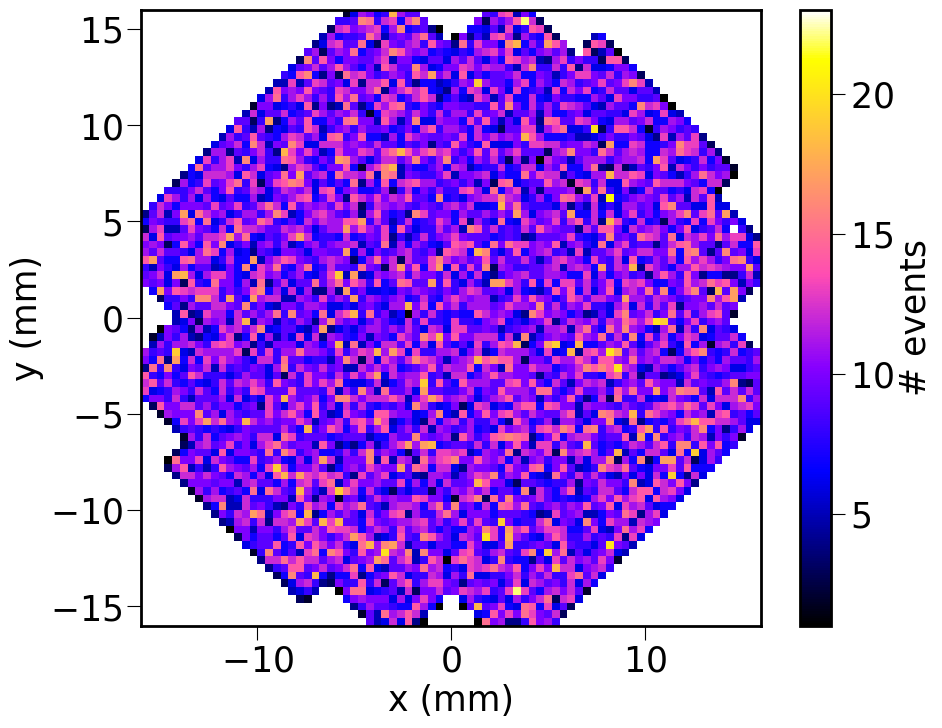

In [6]:
y = plt.hist2d(testdf.x0, testdf.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

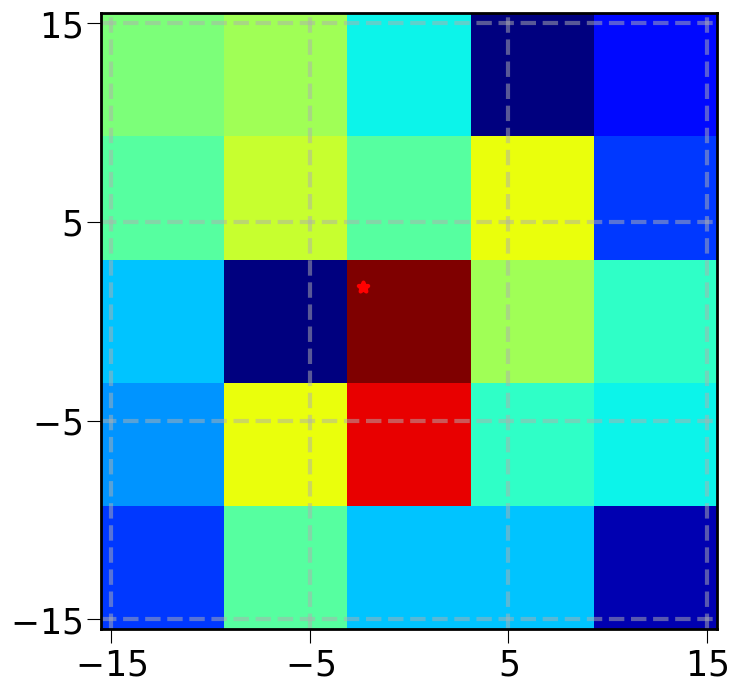

In [7]:
row = testdf.iloc[15]
img = row.image[0].T
x0  = row.x0
y0  = row.y0
plt.imshow(img, origin="lower", extent=extents, cmap="jet")
plt.scatter([x0], [y0], 50, marker="*", color="r")
plt.xticks(ticks)
plt.yticks(ticks)
plt.grid()

# Barycenter

In [8]:
df = testdf
df = (df.groupby(level=0)
        .apply(barycenter, sipm_x, sipm_y)
        .join(df.drop(columns=["image"]))
     )
df.insert(df.shape[1], "dx", df.x - df.x0)
df.insert(df.shape[1], "dy", df.y - df.y0)
df.insert(df.shape[1], "dr", (df.dx**2 + df.dy**2)**0.5)

reco_bb = df

In [9]:
reco_bb

,x,y,x0,y0,z0,r0,dx,dy,dr
event,,,,,,,,,
0,7.002353,1.860000,14.091539,5.830287,-5.177589,15.250040,-7.089186,-3.970287,8.125253
1,-1.811872,-5.067580,-6.336872,-8.972390,-5.169864,10.984522,4.524999,3.904810,5.976886
2,-4.594245,7.181295,-2.727895,13.502290,-5.185869,13.775095,-1.866350,-6.320995,6.590769
3,-3.586973,-5.416092,-7.680037,-8.003661,-5.194487,11.092410,4.093064,2.587569,4.842385
4,5.321667,-4.753333,6.688093,-9.209970,-5.193743,11.382185,-1.366426,4.456636,4.661408
...,...,...,...,...,...,...,...,...,...
49995,-3.022500,4.417500,-7.734983,11.017240,-5.177174,13.461410,4.712483,-6.599740,8.109505
49996,-2.878571,-5.092857,-9.651824,-10.525809,-5.183974,14.281119,6.773252,5.432952,8.682967
49997,5.414480,-3.170136,10.996607,-5.140280,-5.166863,12.138692,-5.582127,1.970145,5.919596


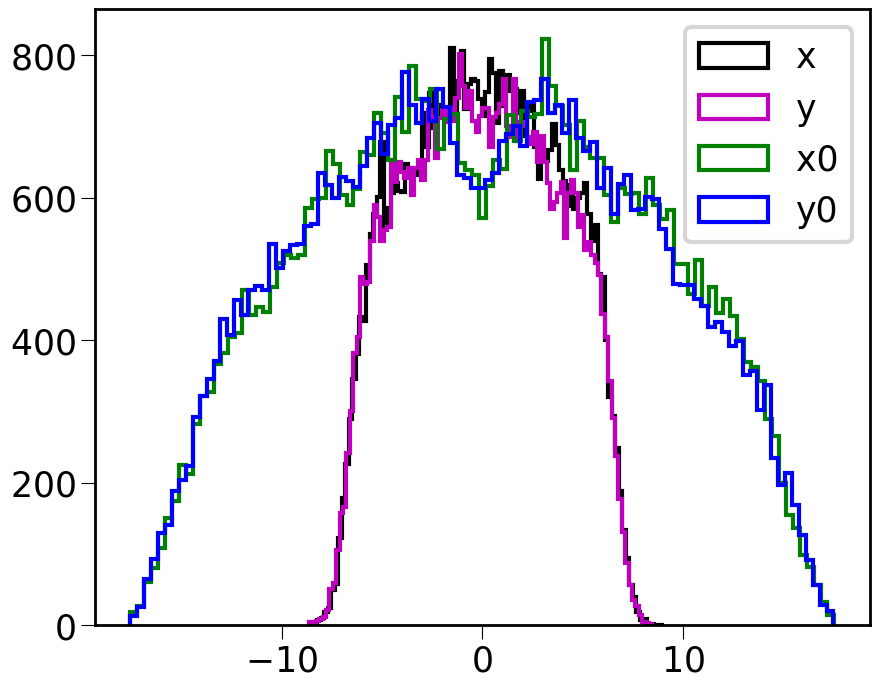

In [10]:
plt.hist(reco_bb.x , 101, histtype="step", label="x");
plt.hist(reco_bb.y , 101, histtype="step", label="y");
plt.hist(reco_bb.x0, 101, histtype="step", label="x0");
plt.hist(reco_bb.y0, 101, histtype="step", label="y0");
plt.legend()

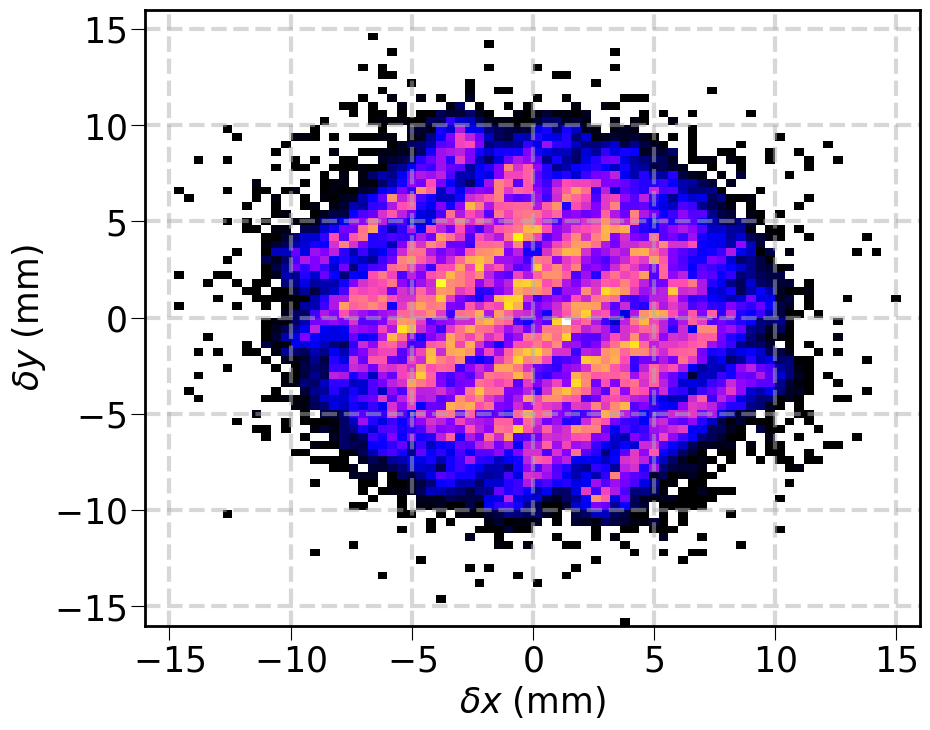

In [11]:
normhist2d(reco_bb.dx, reco_bb.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

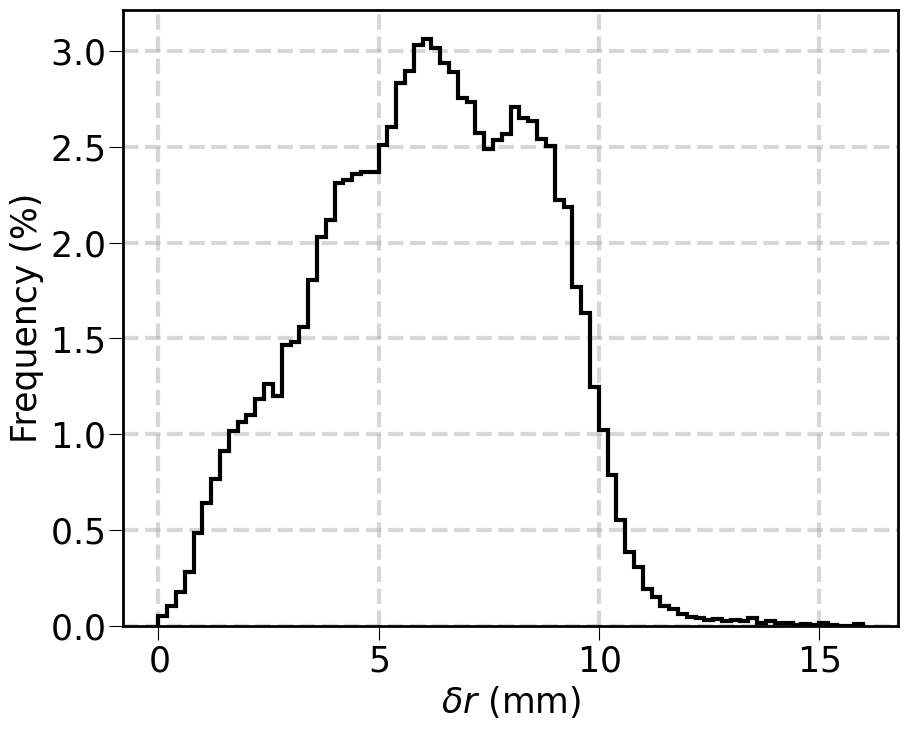

In [12]:
normhist(reco_bb.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()

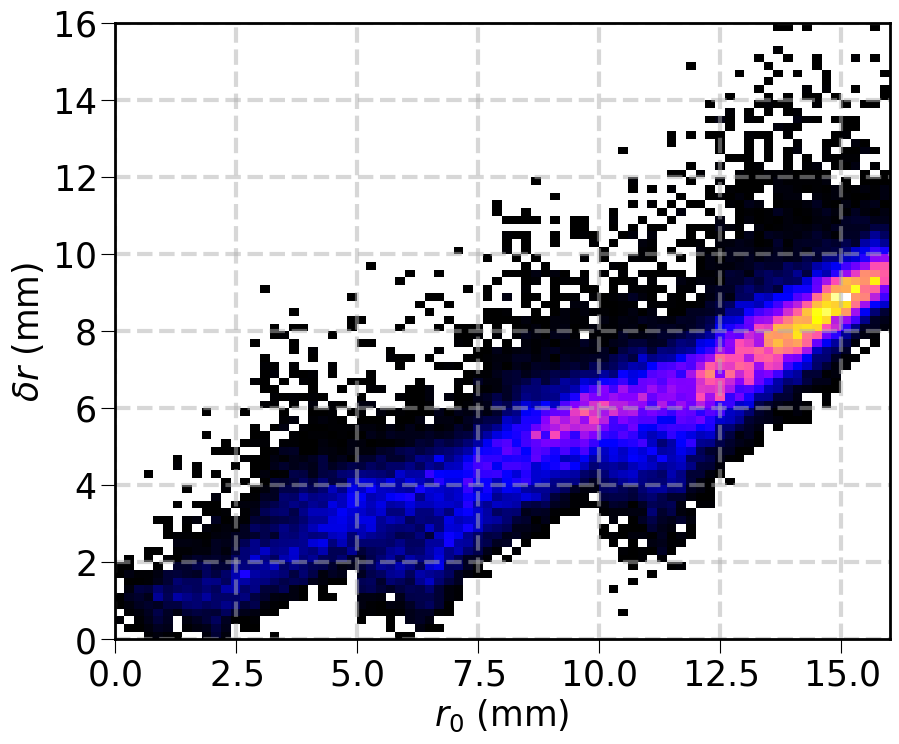

In [13]:
normhist2d(reco_bb.r0, reco_bb.dr, (rbins, drbins))
plt.xlabel("$r_0$ (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()

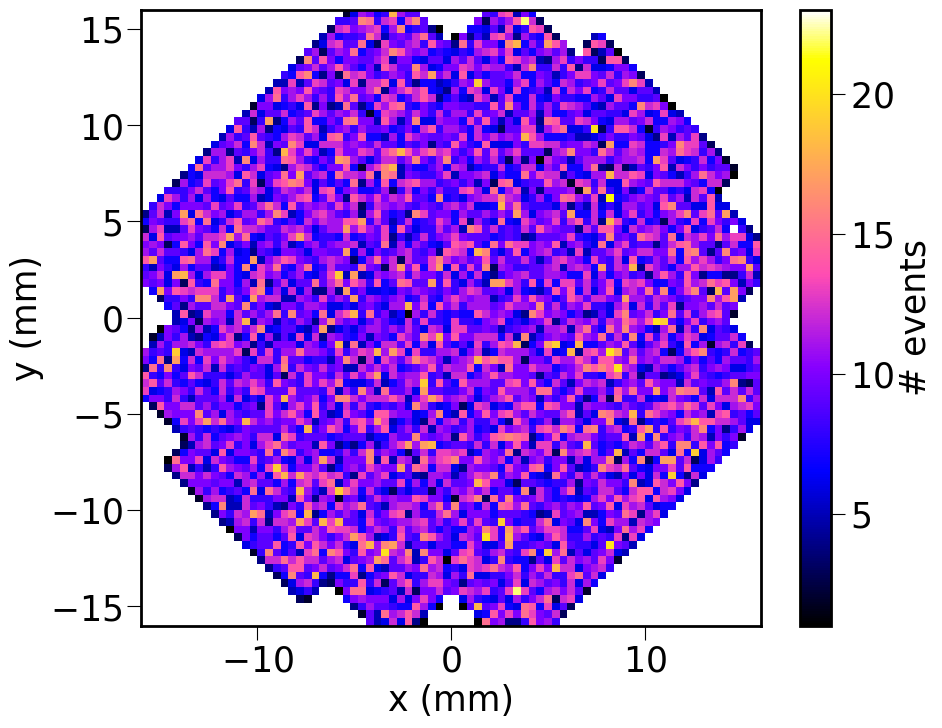

In [14]:
y = plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), cmin=1)[0]
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("# events")
evt_per_bin = y[y>0].mean()

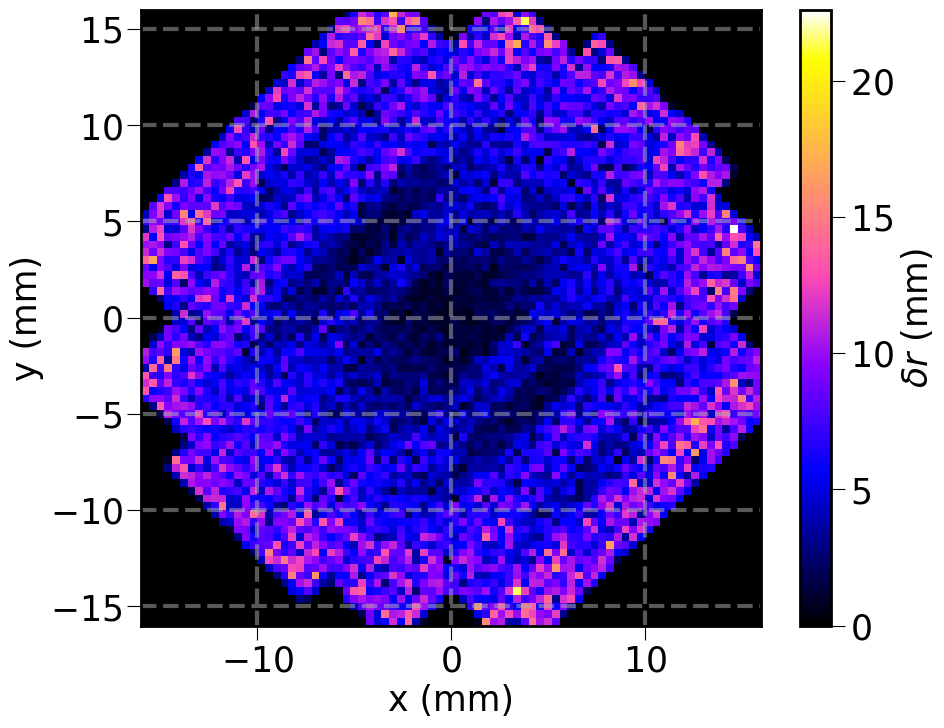

In [15]:
plt.hist2d(reco_bb.x0, reco_bb.y0, (xybins, xybins), weights=reco_bb.dr/evt_per_bin)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("$\delta r$ (mm)")
plt.grid()

# NN

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

In [17]:
class Linear(nn.Module):
    def __init__(self, nx, ny):
        super().__init__()
        self.flatten = nn.Flatten()
        self.l1      = nn.Linear(nx*ny, 64, dtype=float)
        self.l2      = nn.Linear(64, 32, dtype=float)
        self.l3      = nn.Linear(32, 2, dtype=float)
        
    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x =            self.l3(x)
        return x

In [18]:
nfiles    = len(filenames)
train     = pd.concat([imgs_from_file(filename) for filename in filenames[:nfiles//2 ]])
test      = pd.concat([imgs_from_file(filename) for filename in filenames[ nfiles//2:]])
n_train   = len(train)
n_test    = len(test)
img_train = np.concatenate(train.image.values).astype(float)
img_test  = np.concatenate(test .image.values).astype(float)
pos_train = train.loc[:, "x0 y0".split()].values
pos_test  = test .loc[:, "x0 y0".split()].values

img_train = torch.tensor(img_train)
img_test  = torch.tensor(img_test )
pos_train = torch.tensor(pos_train)
pos_test  = torch.tensor(pos_test )

In [19]:
model     = Linear(config.n_sipm_side, config.n_sipm_side)
loss_f    = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
epochs = 500
batch_size = 32
batch_size = 1000

losses = []
for epoch in progressbar(range(epochs)):
    model.train()  # Set the model to training mode
    permutation = torch.randperm(img_train.size(0))  # Shuffle the dataset

    for i in range(0, img_train.size(0), batch_size):
        # Get the next batch
        indices = permutation[i:i + batch_size]
        imgs, pos = img_train[indices], pos_train[indices]

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = loss_f(outputs, pos)

        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

Item 500 of 500 | 0.27 s/item | ETA 0.0 min | Ellapsed 2.2 min


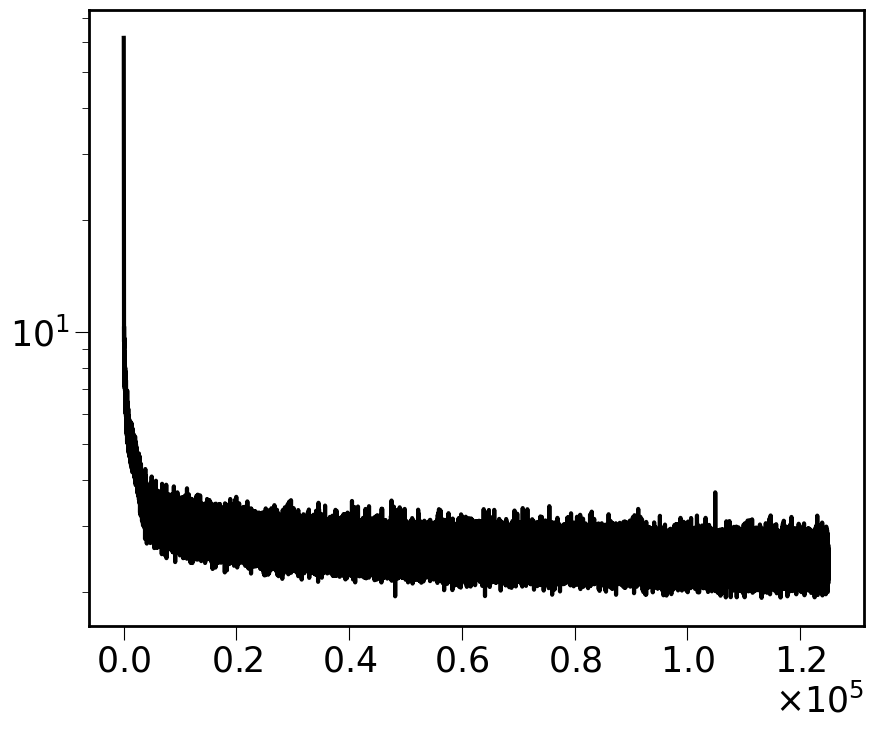

In [21]:
plt.plot(losses)
plt.yscale("log")
plt.show()

In [22]:
model.eval()  # Set the model to evaluation mode
pos_model = model(img_test).detach().numpy()
pos_test_ = pos_test.detach().numpy()

df = test.filter("x0 y0 r0".split())
df = df.assign(  x = pos_model.T[0]
              ,  y = pos_model.T[1]
              , dx = pos_model.T[0] - df.x0
              , dy = pos_model.T[1] - df.y0
              , dr = np.sum((pos_model - pos_test_)**2, axis=1)**0.5
              )

reco_nn = df

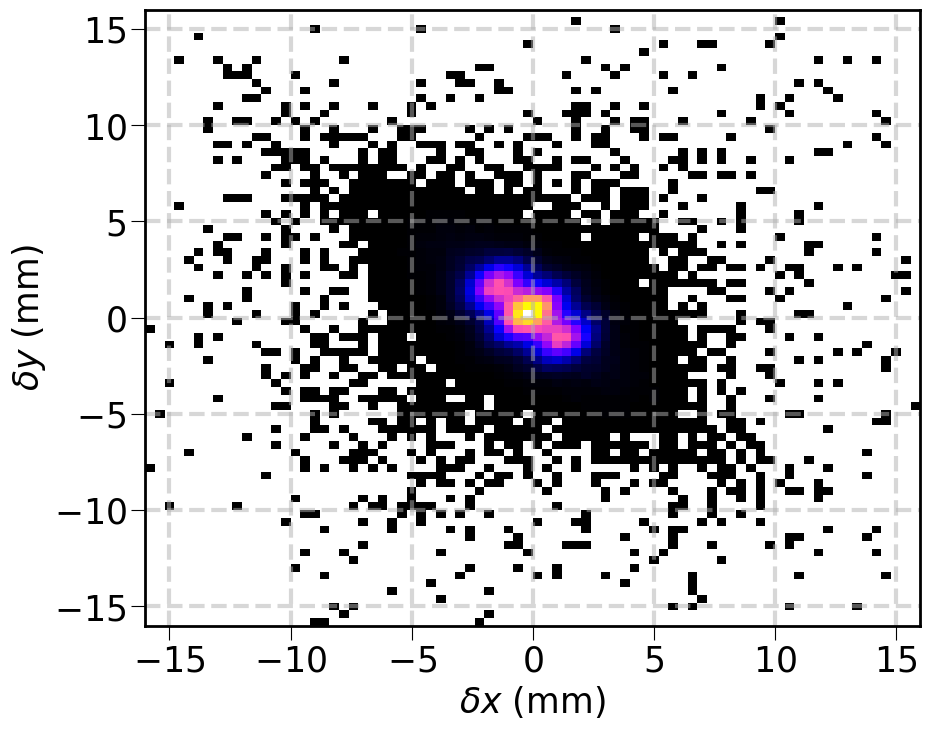

In [23]:
normhist2d(reco_nn.dx, reco_nn.dy, (drbins*2-drbins.max(),)*2)
plt.xlabel("$\delta x$ (mm)")
plt.ylabel("$\delta y$ (mm)")
plt.grid()

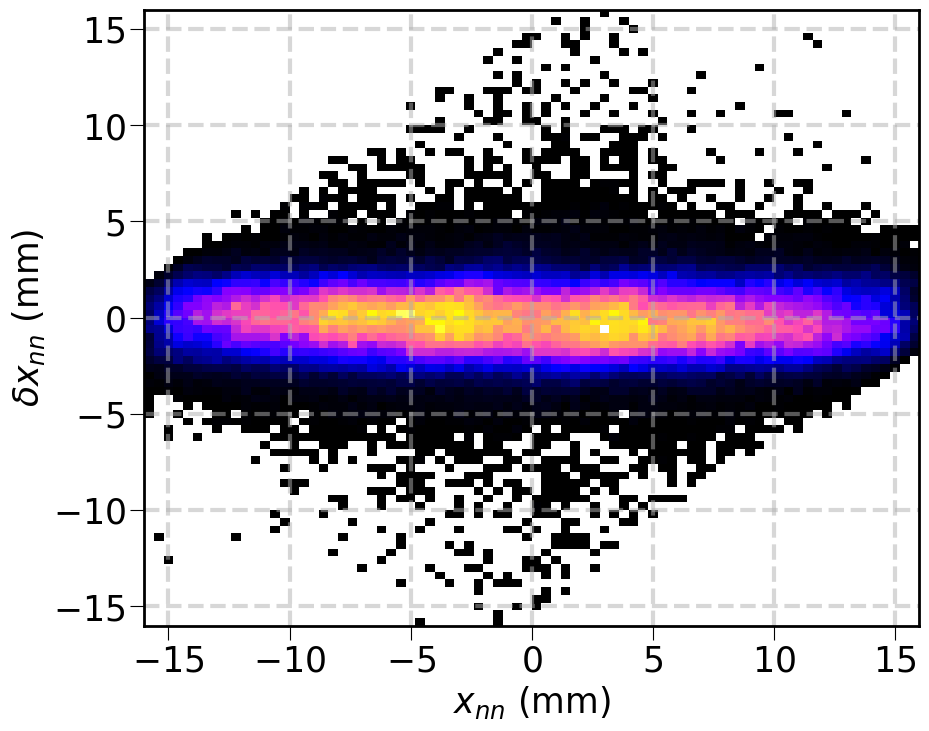

In [24]:
df = reco_nn
#df = df.loc[df.y.abs() < 1]
#df = df.loc[df.x>12]
normhist2d(df.x, df.dx, (xybins, xybins))
plt.xlabel("$x_{nn}$ (mm)")
plt.ylabel("$\delta x_{nn}$ (mm)")
plt.grid()

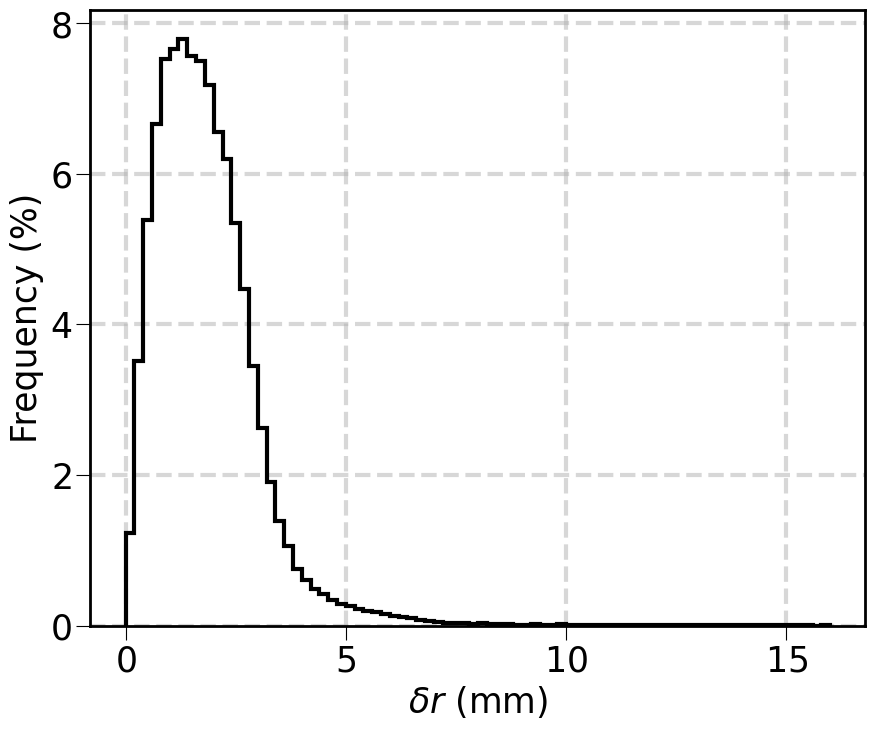

In [25]:
normhist(reco_nn.dr, drbins)
plt.xlabel("$\delta r$ (mm)")
plt.ylabel("Frequency (%)")
plt.grid()
plt.show()

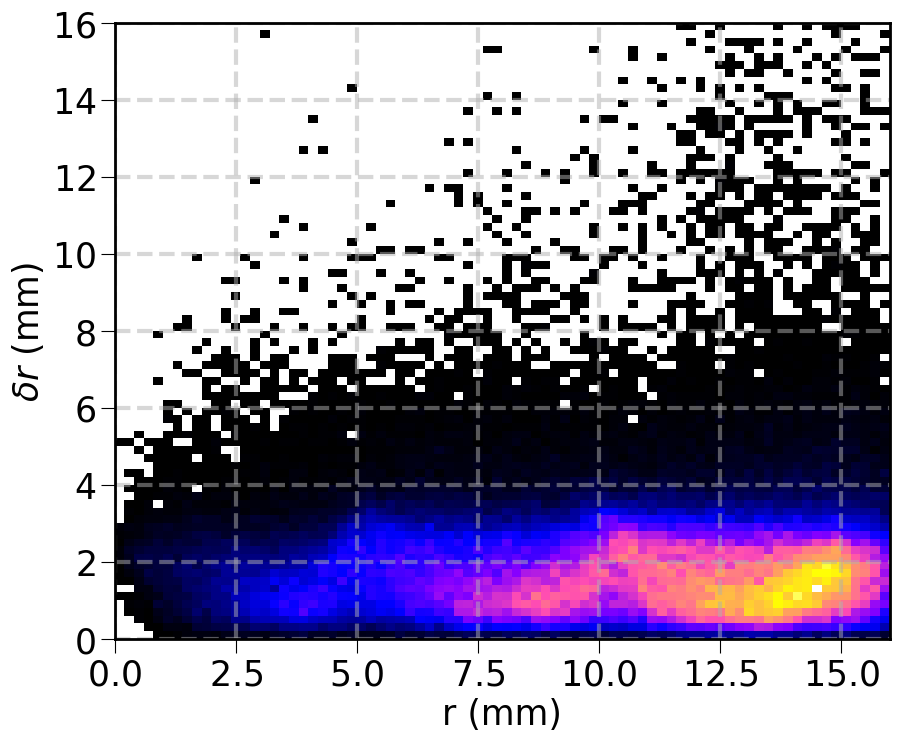

In [26]:
normhist2d(reco_nn.r0, reco_nn.dr, (rbins, drbins))
plt.xlabel("r (mm)")
plt.ylabel("$\delta r$ (mm)")
plt.grid()
plt.show()

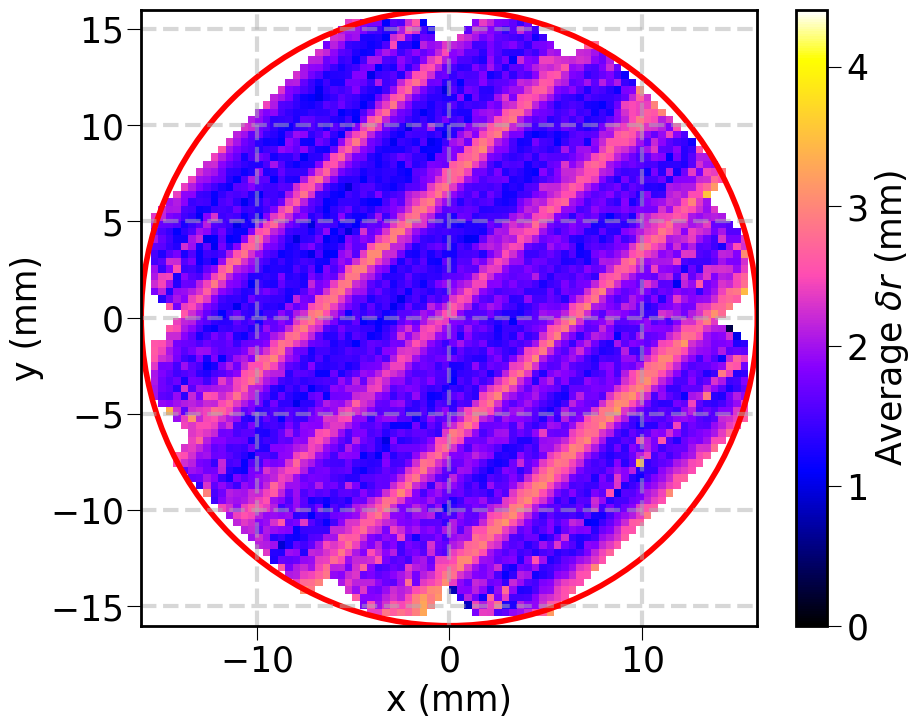

In [27]:
evts = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins))[0]
errs = np.histogram2d(reco_nn.x0, reco_nn.y0, (xybins, xybins), weights=reco_nn.dr)[0]
errs = errs / np.clip(evts, 1, None)
errs = np.where(errs>0, errs, np.nan)
plt.imshow(errs.T, origin="lower", vmin=0, vmax=2.5*np.median(errs[errs>0]), extent=extents)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.colorbar().set_label("Average $\delta r$ (mm)")
draw_el(plt.gca(), rmax)
plt.grid()

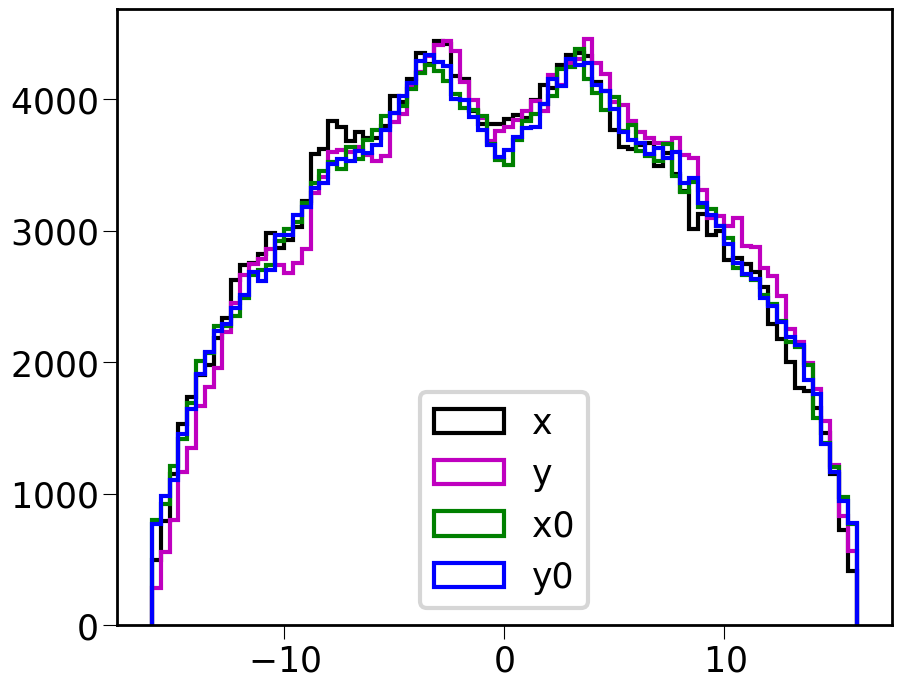

In [28]:
plt.hist(reco_nn.x , xybins, histtype="step", label="x");
plt.hist(reco_nn.y , xybins, histtype="step", label="y");
plt.hist(reco_nn.x0, xybins, histtype="step", label="x0");
plt.hist(reco_nn.y0, xybins, histtype="step", label="y0");
plt.legend()

In [31]:
reco_nn

,x0,y0,r0,x,y,dx,dy,dr
event,,,,,,,,
0,9.923677,-9.135067,13.488099,9.394265,-7.815112,-0.529412,1.319956,1.422168
1,10.411834,7.432322,12.792408,11.122433,7.995521,0.710599,0.563200,0.906722
2,-5.689949,-9.313258,10.913858,-5.004691,-6.964725,0.685257,2.348533,2.446464
3,0.615505,1.091601,1.253172,-1.467535,2.851782,-2.083040,1.760181,2.727140
4,-5.975484,-7.841943,9.859131,-7.872981,-7.787899,-1.897497,0.054044,1.898266
...,...,...,...,...,...,...,...,...
49995,8.311532,3.974090,9.212760,8.039795,4.496111,-0.271737,0.522022,0.588513
49996,-5.582510,6.291044,8.410806,-4.739354,5.960341,0.843156,-0.330703,0.905691
49997,2.100782,13.818130,13.976909,5.160364,11.402912,3.059582,-2.415217,3.897989


In [29]:
output = filenames[0].parent
output = output.parent / (output.stem + "_reco_summary.h5")
reco_nn.to_hdf(output, key="/data", complib="zlib", complevel=4, mode="w")

In [30]:
import datetime
print(f"Last execution: {datetime.datetime.now()}")

Last execution: 2026-03-03 11:28:36.328302
